<a href="https://colab.research.google.com/github/Ravravan/SMS-spam-detection/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

#1. data cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [23]:
#drop last 3cols
#df.drop(columns=['Unnamed: 2','Unnamed: 3',' Unnamed: 4'], inplace=True)

In [24]:
df.sample(5)

,v1,v2
3543,ham,Lol ok ill try to send. Be warned Sprint is de...
4523,ham,I've sent Ì_ my part..
1404,ham,Actually getting ready to leave the house.
614,ham,I called and said all to him:)then he have to ...
4544,ham,Never y lei... I v lazy... Got wat? Dat day Ì_...


In [25]:
#renaming the cols
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [27]:
df.sample(30)

,target,text
5528,ham,Its just the effect of irritation. Just ignore it
3989,spam,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
5206,ham,I will reach ur home in &lt;#&gt; minutes
356,spam,Congratulations ur awarded 500 of CD vouchers ...
3131,ham,I've been barred from all B and Q stores for l...
2008,ham,See the forwarding message for proof
2581,ham,Yup i'm elaborating on the safety aspects and ...
3410,ham,Only once then after ill obey all yours.
3859,ham,Yep. I do like the pink furniture tho.
4142,spam,In The Simpsons Movie released in July 2007 na...


In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
encoder = LabelEncoder()

In [31]:
df['target']=encoder.fit_transform(df['target'])

In [32]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [34]:
#missing values
df.isnull().sum()

,0
target,0
text,0


In [35]:
#check for duplicate values
df.duplicated().sum()

np.int64(403)

In [62]:
#remove duplicate
df =df.drop_duplicates(keep='first')

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df.shape

(5169, 3)

#2.EDA

In [65]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [67]:
#values of data "ham" and 'spam'

df['target'].value_counts()


,count
target,
0,4516
1,653


In [68]:
import matplotlib.pyplot as plt

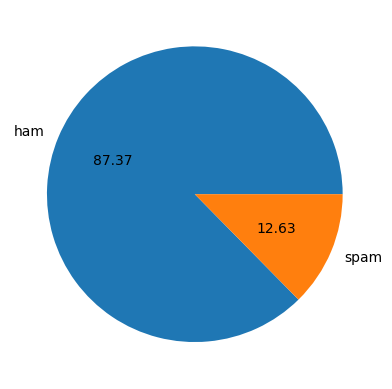

In [69]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [75]:
import nltk

In [76]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [95]:
#number of  character in text
df['num_character'] = df['text'].apply(len)

In [96]:
df.head()

,target,text,num_character,num_words,num_setences,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,111
1,0,Ok lar... Joking wif u oni...,29,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,155
3,0,U dun say so early hor... U c already then say...,49,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,61


In [97]:
#number of words
df['num_words'] = df['text'].apply(lambda x:len((nltk.word_tokenize(x))))

In [98]:
df.head()

,target,text,num_character,num_words,num_setences,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,111
1,0,Ok lar... Joking wif u oni...,29,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,155
3,0,U dun say so early hor... U c already then say...,49,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,61


In [90]:
#number of sentence in text
df['num_setences'] = df['text'].apply(lambda x:len((nltk.sent_tokenize(x))))

In [99]:
df.head()

,target,text,num_character,num_words,num_setences,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,111
1,0,Ok lar... Joking wif u oni...,29,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,155
3,0,U dun say so early hor... U c already then say...,49,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,61


In [105]:
df.drop(columns=['num_characters'],inplace=True)

In [106]:
df.head()

,target,text,num_character,num_words,num_setences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [108]:
df[['num_character','num_words','num_setences']].describe()

,num_character,num_words,num_setences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000
